# Exposure exponents sensitivitiy

In [1]:
##Import different packages
import importlib

import warnings
import os
import cftime
import math
import matplotlib.pyplot as plt
import sys
import datetime as dt
import xarray as xr
import numpy as np
import copy as cp
import pandas as pd
from numpy import nan
from scipy import sparse
import cartopy.crs as ccrs
from timeit import default_timer as timer
from os import mkdir, remove, rmdir
from glob import glob

from climada.engine import Impact, ImpactCalc
from climada.entity import ImpactFunc,ImpactFuncSet

import warnings
warnings.filterwarnings('ignore') #Ignore warnings for making the tutorial's pdf.
warnings.simplefilter('ignore')
import logging
from climada.util.config import LOGGER
LOGGER.setLevel(logging.ERROR) #Ignore CLIMADA warnings for making the tutorial's pdf.

##Load self-written, custom function definitions
from SL_bias_corr import *
from constants import *
from functions_projUncWS import *
idx = pd.IndexSlice

# Load and select hazard data

In [2]:
#Read all ERA5 hazard documents
ds2000_2003 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_00_03')
ds2004_2007 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_04_07')
ds2008_2011 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_08_11')
ds2012_2014 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/wind_gust_12_14')
BE_2015 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2015/data_stream-oper_stepType-max.nc')
BE_2016 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2016/data_stream-oper_stepType-max.nc')
BE_2017 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2017/data_stream-oper_stepType-max.nc')
BE_2018 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2018/data_stream-oper_stepType-max.nc')
BE_2019 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2019/data_stream-oper_stepType-max.nc')
BE_2020 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2020/data_stream-oper_stepType-max.nc')
BE_2021 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2021/data_stream-oper_stepType-max.nc')
BE_2022 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2022/data_stream-oper_stepType-max.nc')
BE_2023 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2023/data_stream-oper_stepType-max.nc')
BE_2024 = xr.open_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Data België/2024/data_stream-oper_stepType-max.nc')

ds_combined_BE = xr.concat([ds2000_2003, ds2004_2007, ds2008_2011, ds2012_2014, BE_2015, BE_2016, BE_2017, BE_2018, BE_2019, BE_2020, BE_2021, BE_2022, BE_2023, BE_2024], dim="valid_time")

era_df = ds_combined_BE.to_dataframe().reset_index()
era_df

era_df

,valid_time,latitude,longitude,fg10,number,expver
0,2000-01-01 00:00:00,51.5,2.50,9.744840,0,0001
1,2000-01-01 00:00:00,51.5,2.75,9.196988,0,0001
2,2000-01-01 00:00:00,51.5,3.00,8.672574,0,0001
3,2000-01-01 00:00:00,51.5,3.25,7.343472,0,0001
4,2000-01-01 00:00:00,51.5,3.50,6.813199,0,0001
...,...,...,...,...,...,...
15748987,2024-12-31 23:00:00,49.5,5.25,10.525099,0,0001
15748988,2024-12-31 23:00:00,49.5,5.50,10.528028,0,0001
15748989,2024-12-31 23:00:00,49.5,5.75,10.328810,0,0001
15748990,2024-12-31 23:00:00,49.5,6.00,9.947950,0,0001


# Load and prepare exposure data

In [3]:
from climada.entity import LitPop

years = range(2014, 2025)

EU_countries = ['Belgium']

##Read metadata
ltpop_info = pd.read_csv('/Users/anne-sophiesimons/Desktop/Climate change projections paper/data/_metadata_countries_v1_2.csv',sep=',')
#Filter the rows where the country is equal to Belgium
ctrs_metadata = ltpop_info[ltpop_info["country_name"].isin(EU_countries)][["country_name","region_id","iso3"]]
#ctrs_regis contains only the region IDs of Belgium. The region ID of Belgium is equal to 56.
ctrs_regids = ctrs_metadata.region_id.tolist()

#All litpop region IDs for Belgium.
BE_regids = ctrs_regids  

#All exponent combinations to check
exponent_combinations = [(0, 0), (0, 0.25), (0, 0.5), (0, 0.75), (0, 1.25),
(0.25, 0), (0.25, 0.25), (0.25, 0.5), (0.25, 0.75), (0.25, 1),
(0.5, 0), (0.5, 0.25), (0.5, 0.5), (0.5, 0.75),
(0.75, 0), (0.75, 0.25), (0.75, 0.5), (0.75, 0.75), (0.75, 1),
(1, 0), (1, 1), 
(1.25, 0), (1.25, 1.25)] 

#Exposure resolution
res_exp = 30


#Save all LitPop objects
litpop_data = {}

for m, n in exponent_combinations:
    for year in years:
        #Generate all LitPop data
        exp = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year=year)
        
        #Save in dictionary
        key = f"m{m}_n{n}_{year}"
        litpop_data[key] = exp

# Load and prepare vulnerability function

In [4]:
##First impact function: Schwierz
#Get the standard European storm impact function from CLIMADA (Schwierz et al. 2010)
from climada.entity.impact_funcs import storm_europe

#Load the Schwierz impact function
impFunc_schw = storm_europe.ImpfStormEurope.from_schwierz()

#Properties of the impact function 
impFunc_schw.id = 1 #Unique ID-number for the impact function
impFunc_schw.haz_type = 'WS' #WS is Wind Storm
impFunc_schw.name = 'Sw2010' #Name of the impact function
impFunc_schw.check() #Check if all properties are correctly

In [5]:
##Second impact function: Cubic Excess over Threshold
#Implement impact function cubic excess over threshold from Klawa 2003
#Import the general ImpactFunc class
from climada.entity import ImpactFunc
#Make a new empty impact function
imp_fun_cub = ImpactFunc()
#Set the hazard type and name
imp_fun_cub.haz_type = 'WS'
imp_fun_cub.name = 'CubEOT'
#Provide unit of the hazard (wind) intensity
imp_fun_cub.intensity_unit = 'm/s'
#Define normalised wind intensities (0 to 1)
imp_fun_cub.intensity = np.linspace(0, 1, num=20)
#Define the damage function: damage increases cubically with intensity
imp_fun_cub.mdd = imp_fun_cub.intensity**3
#Add an extreme value: Above the extreme wind intensity then 100% damage
imp_fun_cub.intensity = np.append(imp_fun_cub.intensity, [40])
imp_fun_cub.mdd = np.append(imp_fun_cub.mdd, [1])
#Probability that there is damage is equal to 100% of all intensities
imp_fun_cub.paa = np.ones(imp_fun_cub.intensity.shape)

#Check if the all the attributes are set correctly
imp_fun_cub.id = 2
imp_fun_cub.check()

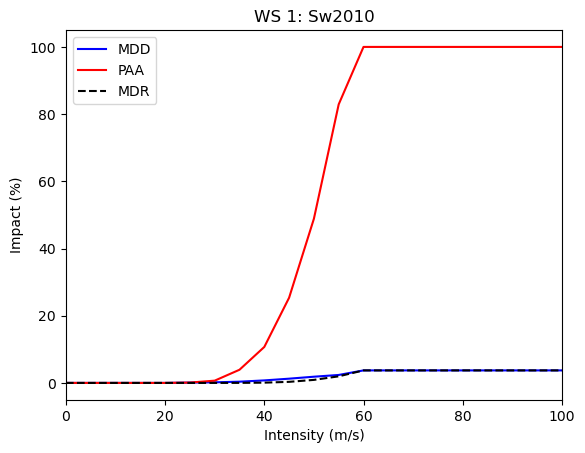

In [6]:
#Generate one impact function set containing all functions
from climada.entity import ImpactFuncSet
#Include the impact functions in the impact function set
#impf_list = [impFunc_schw, imp_fun_cub]
impf_list = [impFunc_schw]

#A list with function names and a dictionary linking names to IDs
impf_namelist = []
impf_dict = {}
#Create an empty impact function set
impf_set = ImpactFuncSet()

#Add each impact function to the set and store its name and ID
for impf in impf_list:
    impfname = impf.name
    impf_namelist.append(impfname)
    impf_dict[impfname] = impf.id
    impf_set.append(impf)
    impf_set.check() #Validate the impact function set

#Plot the impact functions
axs = impf_set.plot()

# Damage calculation

In [7]:
pastname = 'historical' 
timeres = 'valid_time' 
eravar = 'fg10' 

#Impact function setup
impf_dict = impf_dict 
impf_set = impf_set
pp_func_dic = pp_func_dic

#Preprocessing parameters
gst_fact = 1 #Gust factor
qt = 0.98 #Quantile threshold for event detection
cut = 1 #Area threshold for event detection
mask_abs = 22.2 #Absolute threshold for damage calculation
regrid = True #Whether to regrid ERA5 data to rg_res; if True then regrid
rg_res = 0.25 #Horizontal regridding in degree

#CLIMADA constants
haz_type = 'WS' #Hazard type: Wind Storm
haz_id = 1 #Hazard ID
dist_th_cst = 300 #Distance treshold in km to assign centroids

In [8]:
#Initiate DataFrame to save results
metrics = ['aai_agg',1,10,15,20, 25, 30] #Impact metrics to be computed, select aai_agg for Average Annual Damage, and integers for rps

iterables = [metrics,impf_dict.keys()]
col_idx1 = pd.MultiIndex.from_product(iterables,names=["metric","Impf"])
res_df = pd.DataFrame(columns=metrics,index=impf_dict.keys())

In [9]:
from climada.engine import ImpactCalc
import copy as cp
from time import time as timer

# Parameters
saveimpmat = True
saveimpcsv = True
savestats = True
results_folder = '/Users/anne-sophiesimons/Desktop/Climate change projections paper/results/'
return_periods = np.linspace(1,100,num=50)

#Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Save impacts en exceedance frequency curves
impacts_all = {}
efc_all = {}

era_data = {
    2015: BE_2015,
    2016: BE_2016,
    2017: BE_2017,
    2018: BE_2018,
    2019: BE_2019,
    2020: BE_2020,
    2021: BE_2021,
    2022: BE_2022,
    2023: BE_2023,
    2024: BE_2024
}

for key, litpop_exp in litpop_data.items():
    m_n, year_str = key.rsplit("_", 1)  
    year = int(year_str)
    
    print(f"Processing exposure {key} for year {year}")
    
    # Selecteer juiste ERA5 dataset
    era_ds = era_data.get(year)
    if era_ds is None:
        print(f"No ERA5 data for year {year}, skipping.")
        continue


    era_ds = era_ds.rename_vars({eravar: pastname})
    gust_era = gst_fact * era_ds
    if regrid:
        latout = np.arange(min_lat, max_lat+rg_res, rg_res)
        lonout = np.arange(min_lon, max_lon+rg_res, rg_res)
        gust_era = gust_era.interp(latitude=latout, longitude=lonout,
                                   method='linear', kwargs={"fill_value": 'extrapolate'})
    
    #Loop over impact functions
    for impfname, if_id in impf_dict.items():
        preprocess_func = pp_func_dic[impfname]
        
        #Preprocess hazards
        gust_pp = preprocess_func(
            gust_era,
            qt,
            mask_abs=mask_abs,
            cutarea=cut,
            timeres="valid_time",
            pastname='historical',
            futname='historical',
            stack=False
        )
        haz = set_centroids(gust_pp, stack=False, timeres="valid_time", plot=False)
        
        #Copy exposure
        exp_sel = cp.deepcopy(litpop_exp)
        exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
        exp_sel.gdf['impf_' + haz_type] = if_id
        exp_sel.assign_centroids(haz, distance='euclidean', threshold=300)
        exp_sel.check()
        
        #Impact calculation
        start_time = timer()
        impcalc = ImpactCalc(exp_sel, impf_set, haz)
        imp = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
        print(f"Impact calculated in {timer() - start_time:.2f} sec")
        
        #Save with key
        impacts_all[f"{key}_{impfname}"] = imp
        
        #Exceedance frequency
        efc = imp.calc_freq_curve(return_per=return_periods)
        efc_all[f"{key}_{impfname}"] = efc

        if savestats:
            for imet, met in enumerate(metrics):
                if met == 'aai_agg':
                    impmet = imp.aai_agg
                else:
                    impmet = imp.calc_freq_curve(return_per=met).impact
                res_df.loc[f"{key}_{impfname}", met] = impmet

#Convert result DataFrame to float
res_df = res_df.astype(np.float64)

Processing exposure m0_n0_2014 for year 2014
No ERA5 data for year 2014, skipping.
Processing exposure m0_n0_2015 for year 2015
Impact calculated in 0.14 sec
Processing exposure m0_n0_2016 for year 2016
Impact calculated in 0.15 sec
Processing exposure m0_n0_2017 for year 2017
Impact calculated in 0.09 sec
Processing exposure m0_n0_2018 for year 2018
Impact calculated in 0.11 sec
Processing exposure m0_n0_2019 for year 2019
Impact calculated in 0.11 sec
Processing exposure m0_n0_2020 for year 2020
Impact calculated in 0.32 sec
Processing exposure m0_n0_2021 for year 2021
Impact calculated in 0.15 sec
Processing exposure m0_n0_2022 for year 2022
Impact calculated in 0.17 sec
Processing exposure m0_n0_2023 for year 2023
Impact calculated in 0.15 sec
Processing exposure m0_n0_2024 for year 2024
Impact calculated in 0.11 sec
Processing exposure m0_n0.25_2014 for year 2014
No ERA5 data for year 2014, skipping.
Processing exposure m0_n0.25_2015 for year 2015
Impact calculated in 0.14 sec
Pro

In [10]:
res_df

,aai_agg,1,10,15,20,25,30
Sw2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m0_n0_2015_Sw2010,4.377279e+07,4.451694e+06,4.451694e+06,4.451694e+06,4.451694e+06,4.451694e+06,4.451694e+06
m0_n0_2016_Sw2010,4.783886e+07,3.508548e+06,3.508548e+06,3.508548e+06,3.508548e+06,3.508548e+06,3.508548e+06
m0_n0_2017_Sw2010,3.209382e+07,5.151837e+06,5.151837e+06,5.151837e+06,5.151837e+06,5.151837e+06,5.151837e+06
m0_n0_2018_Sw2010,9.153445e+07,1.095621e+07,1.095621e+07,1.095621e+07,1.095621e+07,1.095621e+07,1.095621e+07
...,...,...,...,...,...,...,...
m1.25_n1.25_2020_Sw2010,2.849664e+08,3.777795e+07,3.777795e+07,3.777795e+07,3.777795e+07,3.777795e+07,3.777795e+07
m1.25_n1.25_2021_Sw2010,9.675754e+07,1.301115e+07,1.301115e+07,1.301115e+07,1.301115e+07,1.301115e+07,1.301115e+07
m1.25_n1.25_2022_Sw2010,1.868876e+08,2.436546e+07,2.436546e+07,2.436546e+07,2.436546e+07,2.436546e+07,2.436546e+07
m1.25_n1.25_2023_Sw2010,1.466397e+08,3.184625e+07,3.184625e+07,3.184625e+07,3.184625e+07,3.184625e+07,3.184625e+07


# Metrics

In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Provinces shapefile
provinces = gpd.read_file('/Users/anne-sophiesimons/Documents/Data thesis/gadm41_BEL_2.shp')
provinces = provinces.set_crs(epsg=4326)

#Aggregate impact per province
impact_provincies = {}  

for scenario_name, year_dict in impact_provincies.items():
    for year, series in year_dict.items():
        series.index = series.index.map(province_names)
        impact_provincies[scenario_name][year] = series

for key, imp in impacts_all.items():
    scenario_year, impfname = key.rsplit("_",1)
    scenario, year_str = scenario_year.rsplit("_",1)
    year = int(year_str)
    
    points = litpop_data[f"{scenario}_{year}"].gdf.copy()
    points = points.set_crs(epsg=4326)
    points['impact'] = imp.eai_exp
    
    #Spatial join with provinces
    points_with_polygon = gpd.sjoin(points, provinces, how='left', predicate='within')
    impact_by_polygon = points_with_polygon.groupby('index_right')['impact'].sum().reset_index()
    
    provinces_merged = provinces.merge(
        impact_by_polygon, left_index=True, right_on='index_right', how='left'
    )
    
    if scenario not in impact_provincies:
        impact_provincies[scenario] = {}
    
    impact_provincies[scenario][year] = provinces_merged['impact']

#Compare with Assuralia observations
Assuralia = pd.read_excel('/Users/anne-sophiesimons/Documents/Data thesis/Schade per provincie.xlsx')
assuralia_long = Assuralia.melt(id_vars=['Jaar'], var_name='België', value_name='impact')
assuralia_table = assuralia_long.pivot(index='België', columns='Jaar', values='impact')

#Compute statistics per scenario
years = range(2015, 2025)

for scenario in exponent_combinations:
    scenario_name = f"m{scenario[0]}_n{scenario[1]}"
    model = np.array([impact_provincies[scenario_name][year].sum() for year in years])
    obs = np.array([assuralia_table[year].sum() for year in years])
    
    mask = ~np.isnan(model) & ~np.isnan(obs) & (obs != 0)
    
    mae = np.mean(np.abs(model - obs))
    rmse = np.sqrt(np.mean((model - obs)**2))
    bias = np.mean(model - obs)
    mape = np.mean(np.abs((model[mask]-obs[mask])/obs[mask]))*100
    corr = np.corrcoef(model[mask], obs[mask])[0,1]
    r2 = corr**2
    
    print(f"Scenario {scenario_name}: MAE={mae:.2e}, RMSE={rmse:.2e}, Bias={bias:.2e}, MAPE={mape:.2f}%, R²={r2:.2f}")

Scenario m0_n0: MAE=8.19e+07, RMSE=1.44e+08, Bias=-5.55e+07, MAPE=38.77%, R²=0.32
Scenario m0_n0.25: MAE=8.12e+07, RMSE=1.43e+08, Bias=-5.63e+07, MAPE=39.65%, R²=0.35
Scenario m0_n0.5: MAE=8.05e+07, RMSE=1.42e+08, Bias=-5.74e+07, MAPE=40.30%, R²=0.37
Scenario m0_n0.75: MAE=7.99e+07, RMSE=1.41e+08, Bias=-5.87e+07, MAPE=40.74%, R²=0.38
Scenario m0_n1.25: MAE=8.01e+07, RMSE=1.42e+08, Bias=-6.20e+07, MAPE=41.33%, R²=0.40
Scenario m0.25_n0: MAE=8.06e+07, RMSE=1.42e+08, Bias=-5.74e+07, MAPE=40.68%, R²=0.37
Scenario m0.25_n0.25: MAE=8.03e+07, RMSE=1.41e+08, Bias=-5.78e+07, MAPE=40.84%, R²=0.37
Scenario m0.25_n0.5: MAE=7.99e+07, RMSE=1.41e+08, Bias=-5.88e+07, MAPE=41.20%, R²=0.39
Scenario m0.25_n0.75: MAE=8.03e+07, RMSE=1.41e+08, Bias=-5.99e+07, MAPE=41.67%, R²=0.39
Scenario m0.25_n1: MAE=8.07e+07, RMSE=1.41e+08, Bias=-6.13e+07, MAPE=41.90%, R²=0.40
Scenario m0.5_n0: MAE=8.01e+07, RMSE=1.41e+08, Bias=-5.82e+07, MAPE=41.44%, R²=0.38
Scenario m0.5_n0.25: MAE=8.02e+07, RMSE=1.41e+08, Bias=-5.87e+

In [12]:
#Province_names mapping
province_names = {
    0: 'Brussels',
    1: 'Antwerp',
    2: 'Limburg',
    3: 'East Flanders',
    4: 'Flemish Brabant',
    5: 'West Flanders',
    6: 'Walloon Brabant',
    7: 'Hainaut',
    8: 'Liège',
    9: 'Luxembourg',
    10: 'Namur'
}


for scenario_name, year_dict in impact_provincies.items():
    for year, series in year_dict.items():
        #Change numeric index with provinces name
        impact_provincies[scenario_name][year] = series.rename(province_names)

In [23]:
province_mape = {} 

for scenario in exponent_combinations:
    scenario_name = f"m{scenario[0]}_n{scenario[1]}"
    province_mape[scenario_name] = {}
    
    for province in assuralia_table.index:
        #Modelled damage per province over all years
        model = np.array([impact_provincies[scenario_name][year].loc[province]
                          for year in years])
        
        #Observations per provinces over all years
        obs = assuralia_table.loc[province, years].values
        
        mask = ~np.isnan(model) & ~np.isnan(obs) & (obs != 0)
        
        #Calculate metrics
        if mask.sum() > 0:
            #mape = np.mean(np.abs((model[mask]-obs[mask])/obs[mask]))*100
            #mae = np.mean(np.abs(model[mask]-obs[mask]))
            rmse = np.sqrt(np.mean((model[mask] - obs[mask])**2))
            #bias = np.mean(model[mask] - obs[mask])
        else:
            #mape = np.nan
            #mae = np.nan
            rmse = np.nan
            #bias = np.nan 
        
        province_mape[scenario_name][province] = rmse
province_mape

import pandas as pd

#Nested dictionary to DataFrame
mape_df = pd.DataFrame(province_mape)

mape_df = mape_df.reindex(sorted(mape_df.index))

#Represent table
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', 170)      
print(mape_df)

mape_million = mape_df / 1_000_000

latex_table = mape_million.to_latex(
    float_format="%.2f",
    caption="RMSE per provincie (in miljoenen)",
    label="tab:rmse_provincies"
)

print(latex_table)

                        m0_n0      m0_n0.25       m0_n0.5      m0_n0.75      m0_n1.25      m0.25_n0   m0.25_n0.25    m0.25_n0.5   m0.25_n0.75      m0.25_n1  \
Antwerp          3.049137e+07  2.909716e+07  2.794248e+07  2.709643e+07  2.668788e+07  2.862291e+07  2.792618e+07  2.710603e+07  2.655542e+07  2.634888e+07   
Brussels         6.381603e+06  5.766836e+06  4.636159e+06  3.828181e+06  1.734032e+07  6.037114e+06  5.241591e+06  4.032571e+06  4.649485e+06  1.056424e+07   
East Flanders    3.302317e+07  3.194181e+07  3.120156e+07  3.084978e+07  3.159638e+07  3.078660e+07  3.051161e+07  3.021326e+07  3.024539e+07  3.067865e+07   
Flemish Brabant  1.354823e+07  1.267452e+07  1.205925e+07  1.173487e+07  1.213395e+07  1.198652e+07  1.170231e+07  1.140016e+07  1.133426e+07  1.154851e+07   
Hainaut          2.924024e+07  2.896028e+07  2.885162e+07  2.893270e+07  2.997354e+07  2.836534e+07  2.854688e+07  2.860980e+07  2.884049e+07  2.932012e+07   
Limburg          1.059408e+07  1.047607e+07  1